# Advanced Recipe Data EDA & Persistence
Exploring the ingested recipe database with DuckDB and visual analytics.

In [1]:
import duckdb
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to the persistent database
con = duckdb.connect('recipes.db')

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

## 1. Distribution of Cooking Times
Analyzing how long our recipes take to prepare.

C:\Users\thoma\AppData\Local\Temp\ipykernel_4288\2267785634.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_times, x='total_time_minutes', y='title', palette='viridis')


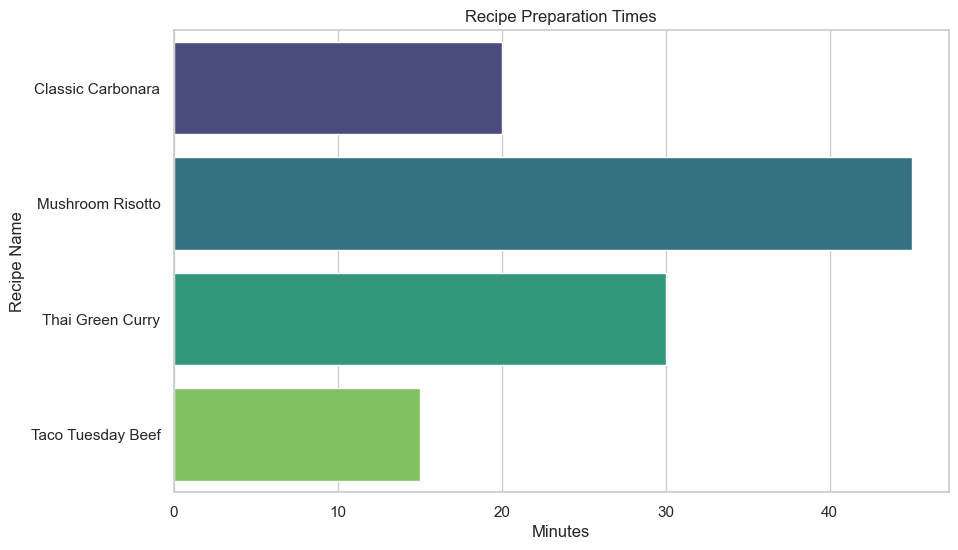

In [2]:
df_times = con.execute("SELECT title, total_time_minutes FROM recipes").df()
sns.barplot(data=df_times, x='total_time_minutes', y='title', palette='viridis')
plt.title('Recipe Preparation Times')
plt.xlabel('Minutes')
plt.ylabel('Recipe Name')
plt.show()

## 2. Ingredient Complexity Analysis
Let's count the number of ingredients per recipe.

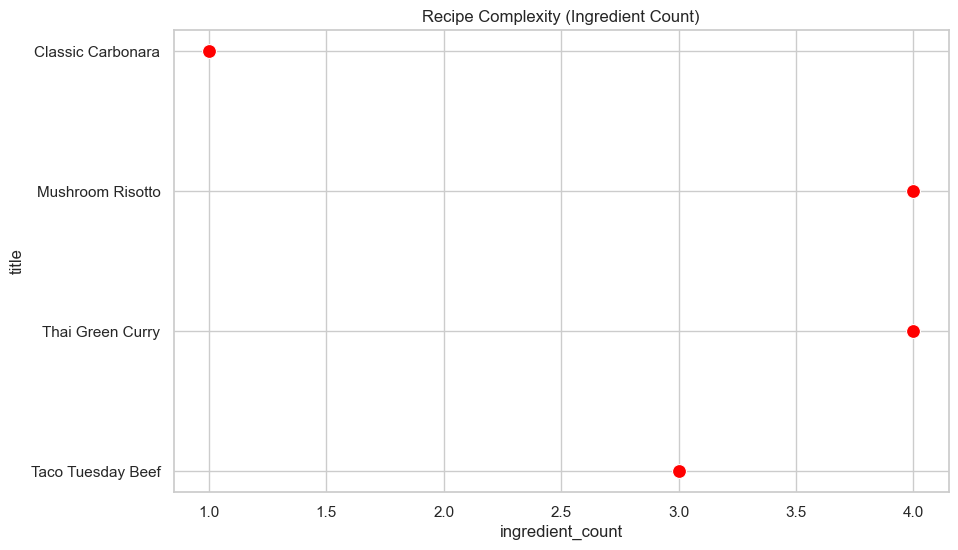

In [3]:
df_complexity = con.execute("""
    SELECT title, 
           len(CAST(ingredients AS JSON[])) as ingredient_count 
    FROM recipes
""").df()

sns.scatterplot(data=df_complexity, x='ingredient_count', y='title', s=100, color='red')
plt.title('Recipe Complexity (Ingredient Count)')
plt.grid(True)
plt.show()

## 3. Step-by-Step Instruction Breakdown
How many steps does each recipe require?

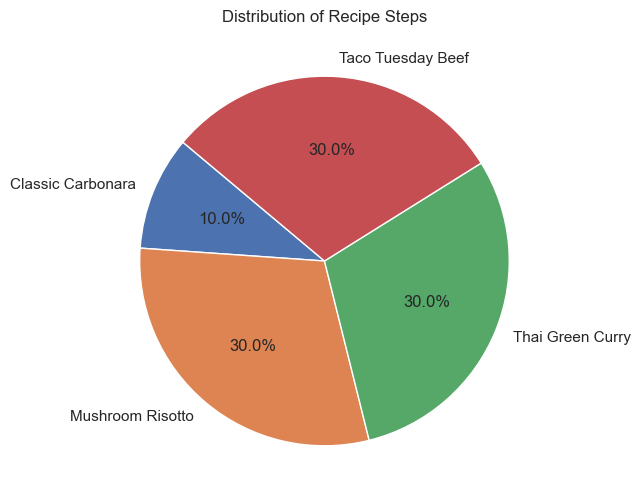

In [4]:
df_steps = con.execute("""
    SELECT title, 
           len(CAST(steps AS JSON[])) as step_count 
    FROM recipes
""").df()

plt.pie(df_steps['step_count'], labels=df_steps['title'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Recipe Steps')
plt.show()

## 4. Search Functionality
Finding recipes that contain specific ingredients (e.g., 'Chicken').

In [5]:
search_term = 'Chicken'
df_search = con.execute(f"""
    SELECT title, ingredients 
    FROM recipes 
    WHERE ingredients::VARCHAR LIKE '%{search_term}%'
""").df()

print(f"Recipes containing '{search_term}':")
df_search

Recipes containing 'Chicken':


,title,ingredients
0,Thai Green Curry,"[{""name"": ""Chicken Breast"", ""amount"": 300, ""un..."


## 5. Statistical Summary
High-level metrics for our kitchen database.

In [6]:
summary = con.execute("""
    SELECT count(*) as total_recipes, 
           avg(total_time_minutes) as avg_time,
           max(total_time_minutes) as max_time,
           min(total_time_minutes) as min_time
    FROM recipes
""").df()
summary

,total_recipes,avg_time,max_time,min_time
0,4,27.5,45,15
